# E2a — 레이어별 K± / C± 프로브 AUROC (p8s-v2)

v2로 추출한 CQ hidden에서 층마다 선형 프로브를 학습해, K± / C± 정보가
어느 층에서 얼마나 decodable한지 측정한다.

프로브는 **최종 방법이 아니다.** K 라벨로 학습하므로 training-free가 아니며,
PKS(E10a)가 도달할 수 있는 상한을 보여주는 진단 기준선이다.

| 항목 | 규약 |
|---|---|
| 분할 | 질문 단위 GroupKFold(5). 같은 질문의 C+/C− 쌍은 항상 같은 fold |
| 모델 | StandardScaler → LogisticRegression(C=0.1) |
| fit 범위 | scaler·probe 모두 train fold에서만 (누수 방지) |
| 입력 | prefill 마지막 토큰 hidden |

런타임: **CPU로 충분하다.**


## 0. 환경 + CONFIG

In [5]:
!pip -q install -U scikit-learn

import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline

from google.colab import drive
drive.mount('/content/drive')

P9 = "/content/drive/MyDrive/Grad_share/data_share/P9/"

CONFIG = {
    "HIDDEN":     "/content/drive/MyDrive/p8s/E1a_v2_dy/hidden_cq.npz",
    "OUT_DIR":   "/content/drive/MyDrive/p8s/E2a_v2_dy",
    "DROP_EMBED": True,   # index 0(embedding) 제거 → 층 번호가 1-based decoder layer와 일치
    "N_SPLITS":  5,
    "LOGREG_C":  0.1,
    "GATE_LO":   8,       # GATE 1 구간
    "GATE_HI":   14,
    "GATE_THR":  0.65,
}
os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 데이터 로드

In [6]:
z = np.load(CONFIG["HIDDEN"], allow_pickle=True)
print("keys:", z.files)
for k in ["prompt_version", "prompt_md5", "mode", "layer_note"]:
    if k in z.files:
        print(f"  {k}: {z[k]}")

H = z["H"]
if CONFIG["DROP_EMBED"]:
    H = H[:, 1:, :]       # embedding 제거
    layer_offset = 1      # 배열 index 0 == decoder layer 1
else:
    layer_offset = 0

groups = np.asarray(z["question"]).astype(str)
kside  = np.asarray(z["kside"]).astype(str)
ctx    = np.asarray(z["ctx_label"]).astype(str)

y_K = np.array([1 if s.strip().startswith("K+") else 0 for s in kside])
y_C = np.array([1 if s.strip().startswith("C+") else 0 for s in ctx])

print(f"\nH={H.shape}  questions={len(set(groups))}")
print(f"K+ {y_K.sum()} / K- {(1-y_K).sum()}   C+ {y_C.sum()} / C- {(1-y_C).sum()}")

keys: ['H', 'question', 'kside', 'ctx_label', 'row_uid', 'prompt_version', 'prompt_md5', 'mode', 'layer_note']
  prompt_version: p8s-v2
  prompt_md5: 20959a4c34203ea0866d030baf23595d
  mode: cq
  layer_note: index 0 = embedding, 1..L = decoder layer

H=(1224, 32, 4096)  questions=612
K+ 756 / K- 468   C+ 612 / C- 612


## 1-b. K± 라벨 교체 (재판정본 수령 후에만 실행)

E1a의 closed-book 재판정 결과를 받으면 이 셀을 실행한다. 받기 전에는 **건너뛴다.**

- **hidden은 재추출하지 않는다.** 프롬프트가 같으므로 hidden 값은 동일하다. 바뀌는 것은 `kside` 라벨뿐이다.
- **C± 곡선은 변하지 않아야 한다.** `ctx_label`은 데이터 구성 시 정해진 값이라 프롬프트와 무관하다.
  재실행 결과에서 C± 값이 달라지면 매핑이나 코드에 문제가 있다는 신호다. 검산으로 쓸 것.
- 행 순서가 다를 수 있으므로 `question` 기준으로 매핑한다.
- **라벨 변경률을 반드시 기록한다.** 이 수치 자체가 보고 재료다.
  변경이 적으면(5% 이하) v1 기반 기존 결과를 조건부로 이월할 근거가 되고,
  크면(15% 이상) v1 결과 전체를 인용할 수 없다는 근거가 된다.

실행 후 **"2. Fold 고정" 셀부터 아래로 전부 다시 실행**한다. `y_K`가 바뀌었으므로 fold도 다시 만들어야 한다.

In [ ]:
new = pd.read_csv("<현경이 준 CSV 경로>")
# question 기준으로 매핑 (행 순서가 다를 수 있으므로)
m = dict(zip(new["question"].astype(str), new["kside"].astype(str)))
kside_v2 = np.array([m[q] for q in groups])

# 얼마나 바뀌었는지 먼저 확인
changed = (kside_v2 != kside).sum()
print(f"라벨 변경: {changed}/{len(kside)} ({changed/len(kside)*100:.1f}%)")

y_K = np.array([1 if s.strip().startswith("K+") else 0 for s in kside_v2])
print(f"K+ {y_K.sum()} / K- {(1-y_K).sum()}")

## 2. Fold 고정 + 누수 점검

4-way 비교와 층 비교가 완전히 같은 분할을 쓰도록 fold를 한 번만 만든다.

In [7]:
FOLDS = list(GroupKFold(n_splits=CONFIG["N_SPLITS"]).split(
    np.zeros(len(groups)), y_K, groups=groups))

rows = []
for k, (tr, te) in enumerate(FOLDS):
    overlap = len(set(groups[tr]) & set(groups[te]))
    assert overlap == 0, f"fold {k} 질문 누수 {overlap}"
    rows.append(dict(fold=k, n_train=len(tr), n_test=len(te),
                     K_pos=int(y_K[te].sum()), K_neg=int((1-y_K[te]).sum()),
                     C_pos=int(y_C[te].sum()), C_neg=int((1-y_C[te]).sum())))
split_df = pd.DataFrame(rows)
split_df.to_csv(os.path.join(CONFIG["OUT_DIR"], "e2a_split_check.csv"), index=False)
print("[OK] fold 간 질문 겹침 0")
print(split_df.to_string(index=False))

[OK] fold 간 질문 겹침 0
 fold  n_train  n_test  K_pos  K_neg  C_pos  C_neg
    0      978     246    166     80    123    123
    1      978     246    134    112    123    123
    2      980     244    146     98    122    122
    3      980     244    146     98    122    122
    4      980     244    164     80    122    122


## 3. 층별 프로브

In [8]:
def probe_layer(X, y):
    """GroupKFold OOF. fold별 AUROC 리스트 반환."""
    scores = []
    for tr, te in FOLDS:
        if len(np.unique(y[te])) < 2 or len(np.unique(y[tr])) < 2:
            scores.append(np.nan); continue
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
        clf.fit(X[tr], y[tr])
        scores.append(roc_auc_score(y[te], clf.predict_proba(X[te])[:, 1]))
    return scores

res_rows = []
for li in range(H.shape[1]):
    X = H[:, li, :].astype(np.float64)
    line = []
    for name, y in [("K", y_K), ("C", y_C)]:
        s = probe_layer(X, y)
        res_rows.append(dict(layer=li + layer_offset, label=name,
                             auroc_mean=float(np.nanmean(s)),
                             auroc_sd=float(np.nanstd(s, ddof=1)),
                             **{f"fold{i}": float(v) for i, v in enumerate(s)}))
        line.append(f"{name}={np.nanmean(s):.3f}")
    print(f"L{li + layer_offset:>2}  " + "  ".join(line), flush=True)

res = pd.DataFrame(res_rows)
res.to_csv(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.csv"), index=False)

L 1  K=0.689  C=0.520
L 2  K=0.723  C=0.529
L 3  K=0.731  C=0.542
L 4  K=0.760  C=0.560
L 5  K=0.785  C=0.585
L 6  K=0.781  C=0.604
L 7  K=0.780  C=0.616
L 8  K=0.802  C=0.624
L 9  K=0.801  C=0.676
L10  K=0.815  C=0.712
L11  K=0.810  C=0.758
L12  K=0.799  C=0.818
L13  K=0.782  C=0.845
L14  K=0.805  C=0.907
L15  K=0.799  C=0.931
L16  K=0.799  C=0.934
L17  K=0.804  C=0.933
L18  K=0.794  C=0.924
L19  K=0.776  C=0.920
L20  K=0.778  C=0.912
L21  K=0.782  C=0.908
L22  K=0.776  C=0.901
L23  K=0.776  C=0.890
L24  K=0.770  C=0.882
L25  K=0.758  C=0.868
L26  K=0.746  C=0.866
L27  K=0.741  C=0.863
L28  K=0.750  C=0.858
L29  K=0.754  C=0.858
L30  K=0.748  C=0.855
L31  K=0.753  C=0.848
L32  K=0.746  C=0.829


## 4. 결과표 + GATE 1 판정

In [9]:
K = res[res.label == "K"]
C = res[res.label == "C"]

best_K = K.loc[K.auroc_mean.idxmax()]
best_C = C.loc[C.auroc_mean.idxmax()]
print(f"K± 전층 최고: L{int(best_K.layer)}  {best_K.auroc_mean:.3f} (sd {best_K.auroc_sd:.3f})")
print(f"C± 전층 최고: L{int(best_C.layer)}  {best_C.auroc_mean:.3f} (sd {best_C.auroc_sd:.3f})")
print("\n※ v1 참고값: CQ→CQ 0.810 (L13). 단 v1은 평문 프롬프트 조건이라 직접 비교 주의")

band = K[(K.layer >= CONFIG["GATE_LO"]) & (K.layer <= CONFIG["GATE_HI"])]
gb = band.loc[band.auroc_mean.idxmax()]
gate = dict(band=f"L{CONFIG['GATE_LO']}-L{CONFIG['GATE_HI']}",
            layer_base="1-based decoder layer" if CONFIG["DROP_EMBED"] else "raw index",
            best_layer=int(gb.layer), best_auroc=round(float(gb.auroc_mean), 4),
            sd=round(float(gb.auroc_sd), 4), threshold=CONFIG["GATE_THR"],
            passed=bool(gb.auroc_mean >= CONFIG["GATE_THR"]))
with open(os.path.join(CONFIG["OUT_DIR"], "e2a_gate.json"), "w") as f:
    json.dump(gate, f, ensure_ascii=False, indent=2)
print("\n[GATE 1]", json.dumps(gate, ensure_ascii=False))

print("\n=== 층별 표 ===")
print(res.pivot_table(index="layer", columns="label",
                      values=["auroc_mean", "auroc_sd"]).round(3).to_string())

K± 전층 최고: L10  0.815 (sd 0.037)
C± 전층 최고: L16  0.934 (sd 0.010)

※ v1 참고값: CQ→CQ 0.810 (L13). 단 v1은 평문 프롬프트 조건이라 직접 비교 주의

[GATE 1] {"band": "L8-L14", "layer_base": "1-based decoder layer", "best_layer": 10, "best_auroc": 0.8151, "sd": 0.0368, "threshold": 0.65, "passed": true}

=== 층별 표 ===
      auroc_mean        auroc_sd       
label          C      K        C      K
layer                                  
1          0.520  0.689    0.011  0.042
2          0.529  0.723    0.011  0.042
3          0.542  0.731    0.007  0.055
4          0.560  0.760    0.008  0.056
5          0.585  0.785    0.016  0.035
6          0.604  0.781    0.020  0.030
7          0.616  0.780    0.022  0.044
8          0.624  0.802    0.022  0.024
9          0.676  0.801    0.022  0.027
10         0.712  0.815    0.009  0.037
11         0.758  0.810    0.021  0.032
12         0.818  0.799    0.018  0.040
13         0.845  0.782    0.015  0.027
14         0.907  0.805    0.013  0.022
15         0.931  0.799    

## 5. 곡선

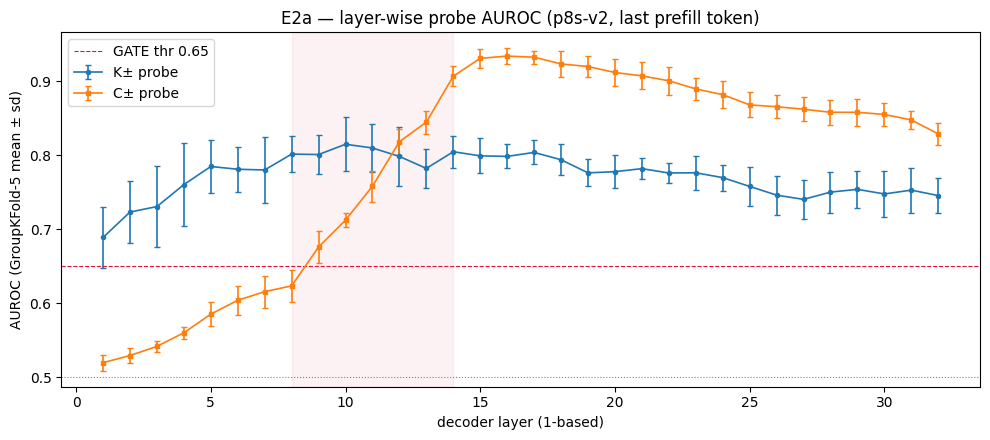

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for d, style, name in [(K, "-o", "K± probe"), (C, "-s", "C± probe")]:
    d = d.sort_values("layer")
    ax.errorbar(d.layer, d.auroc_mean, yerr=d.auroc_sd, fmt=style, ms=3,
                lw=1.2, capsize=2, label=name)
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.axhline(CONFIG["GATE_THR"], color="crimson", lw=0.8, ls="--",
           label=f"GATE thr {CONFIG['GATE_THR']}")
ax.axvspan(CONFIG["GATE_LO"], CONFIG["GATE_HI"], color="crimson", alpha=0.06)
ax.set_xlabel("decoder layer" + (" (1-based)" if CONFIG["DROP_EMBED"] else " (raw index)"))
ax.set_ylabel("AUROC (GroupKFold-5 mean ± sd)")
ax.set_title("E2a — layer-wise probe AUROC (p8s-v2, last prefill token)")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.png"), dpi=150)
plt.show()

## 해석 시 주의

- **층 간 0.02 차이는 fold sd(이전 실험 0.025~0.057) 안에 묻힌다.** 최고층을 단정하지 말고
  고원(plateau) 구간으로 보고할 것.
- **K± 봉우리가 주입 시작 층(L14~15)보다 앞이면** 1-pass 설계가 유지된다.
- **C± 곡선과 겹쳐 본다.** 두 봉우리가 같은 층이면 K와 C 정보가 얽혀 있을 가능성이 있다.
- **층 번호 base를 반드시 명시한다.** P9/P10 인덱싱이 한 층 어긋난 전례가 있다.
- K± 라벨이 아직 v1 기준이면 **혼합 조건**임을 결과에 함께 적을 것.

## *통제* 추가실험

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 통제 1: 질문 텍스트만으로 K를 맞힐 수 있는가 (hidden 미사용)
q_text = np.asarray(z["question"]).astype(str)

def text_baseline(y):
    scores = []
    for tr, te in FOLDS:
        vec = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)
        Xtr = vec.fit_transform(q_text[tr])
        Xte = vec.transform(q_text[te])
        clf = LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000)
        clf.fit(Xtr, y[tr])
        scores.append(roc_auc_score(y[te], clf.predict_proba(Xte)[:, 1]))
    return np.array(scores)

# 통제 2: 질문 길이만으로 (가장 단순한 난이도 proxy)
q_len = np.array([len(s.split()) for s in q_text]).reshape(-1, 1).astype(float)

def len_baseline(y):
    scores = []
    for tr, te in FOLDS:
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
        clf.fit(q_len[tr], y[tr])
        scores.append(roc_auc_score(y[te], clf.predict_proba(q_len[te])[:, 1]))
    return np.array(scores)

tf_K, ln_K = text_baseline(y_K), len_baseline(y_K)
L1  = K[K.layer == 1].auroc_mean.iloc[0]
top = K.auroc_mean.max()

print(f"TF-IDF(question) → K : {tf_K.mean():.3f} (sd {tf_K.std(ddof=1):.3f})")
print(f"질문 길이 → K        : {ln_K.mean():.3f} (sd {ln_K.std(ddof=1):.3f})")
print(f"hidden L1 → K        : {L1:.3f}")
print(f"hidden 최고(L{int(K.loc[K.auroc_mean.idxmax()].layer)}) → K: {top:.3f}")
print(f"\n표상 상승분 = 최고 − TF-IDF = {top - tf_K.mean():+.3f}")

pd.DataFrame({"baseline": ["tfidf_question", "question_length"],
              "auroc_mean": [tf_K.mean(), ln_K.mean()],
              "auroc_sd": [tf_K.std(ddof=1), ln_K.std(ddof=1)]}
             ).to_csv(os.path.join(CONFIG["OUT_DIR"], "e2a_text_baseline.csv"), index=False)

TF-IDF(question) → K : 0.724 (sd 0.067)
질문 길이 → K        : 0.578 (sd 0.038)
hidden L1 → K        : 0.689
hidden 최고(L10) → K: 0.815

표상 상승분 = 최고 − TF-IDF = +0.091


## 추가실험: 표상 기여를 더 정직하게 재보기

### TF-IDF란

질문 문장을 단어 빈도 벡터로 바꾸는 고전적 방법이다. 모델 내부와 무관하다.

* TF (term frequency): 이 문서에 그 단어가 몇 번 나왔나
* IDF (inverse document frequency): 그 단어가 전체 문서 중 몇 개에 나왔나. 흔한 단어일수록 가중치를 낮춘다



"What genre is Kanoon?" → [what: 0.1, genre: 0.4, kanoon: 0.9, ...] 같은 희소 벡터가 된다.

흔한 what은 낮고, 드문 kanoon은 높다.

여기에 로지스틱 회귀를 붙이면 "어떤 단어가 들어간 질문이 K−인가"를 학습한다. 0.724가 나왔다는 것은 질문 단어만으로 상당히 맞힌다는 뜻이다.


In [20]:
def oof_scores(X_getter, y, tfidf=False):
    s = np.full(len(y), np.nan)
    for tr, te in FOLDS:
        if tfidf:
            vec = TfidfVectorizer(lowercase=True, ngram_range=(1,2), min_df=2)
            Xtr, Xte = vec.fit_transform(q_text[tr]), vec.transform(q_text[te])
            clf = LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000).fit(Xtr, y[tr])
            s[te] = clf.decision_function(Xte)
        else:
            X = X_getter
            clf = make_pipeline(StandardScaler(),
                                LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
            clf.fit(X[tr], y[tr])
            s[te] = clf.decision_function(X[te])
    return s

LAYER = 10
s_tf  = oof_scores(None, y_K, tfidf=True)
s_hid = oof_scores(H[:, LAYER-1, :].astype(np.float64), y_K)

print("상관계수:", np.corrcoef(s_tf, s_hid)[0,1].round(3))
print("tfidf 단독 :", round(roc_auc_score(y_K, s_tf), 3))
print("hidden 단독:", round(roc_auc_score(y_K, s_hid), 3))

# 두 1차원 점수를 결합 (이제 공평하다)
X2 = np.column_stack([s_tf, s_hid])
s_both = oof_scores(X2, y_K)
print("두 점수 결합:", round(roc_auc_score(y_K, s_both), 3))

상관계수: 0.552
tfidf 단독 : 0.711
hidden 단독: 0.803
두 점수 결합: 0.797


1. 추가실험 1: 표면 베이스라인

모델 내부를 아예 안 보고 질문 문장에 있는 단어만으로 K+-를 맞추게 시켰다 (TF-IDF).

결과: 0.711

질문 단어만 봐도 대부분 맞힌다.

2. 추가실험 2: 겹치는지 확인

* hidden이 질문 표면과 다른 것을 보고 있다 -> probe 결과 무효...
* hidden이 다른 것도 보고 있다. -> probe 결과 유효!

결과: 상관계수 -> 0.552

결합해도 개선 없음 — TF-IDF 점수를 hidden에 얹어봤더니 0.803 → 0.797로 오히려 미세하게 떨어졌다.

즉 TF-IDF가 아는 정보는 hidden에 이미 들어 있다.

질문 표면이 아는 것 (0.711)  ⊂  hidden이 아는 것 (0.803)
                    